# 10. Differential features

The other tutorials ask which perturbations had an effect. This one asks which features
changed. That is a hypothesis test with replicate structure, and image-based profiling has
mostly adopted its testing practice from single-cell transcriptomics without the argument that
settled the question there.

The notebook is an investigation. `tl.effect_size` already reports a per-feature difference
and a Mann-Whitney p-value, so a new function needs a reason to exist. Of three candidate
reasons, two do not hold up on a real screen, and the one that does is not the most obvious.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

import mantispy as mt

## The unit that was randomized

A well of 300 cells is not 300 independent observations of a treatment. The cells share the
well's confluency, focus and plate position. Single-cell transcriptomics settled on pseudobulk
for this: aggregate to the unit that was randomized, then test.

The cost of ignoring this is easy to measure with a null. Take control wells only, split them
into two arbitrary halves, and test for differences. Every feature called is a false positive
by construction.

In [2]:
def null_split(well_sd, n_wells=16, n_cells=300, n_features=500, seed=1):
    """Control wells only, split in half. Nothing differs between the halves."""
    rng = np.random.default_rng(seed)
    well_of_cell = np.repeat(np.arange(n_wells), n_cells)
    cells = rng.normal(size=(n_wells * n_cells, n_features))
    cells += rng.normal(scale=well_sd, size=(n_wells, n_features))[well_of_cell]

    left_cell = well_of_cell < n_wells // 2
    _, per_cell = stats.mannwhitneyu(cells[left_cell], cells[~left_cell], axis=0)

    wells = np.stack([cells[well_of_cell == w].mean(axis=0) for w in range(n_wells)])
    left = np.arange(n_wells) < n_wells // 2
    _, per_well = stats.ttest_ind(wells[left], wells[~left], axis=0)

    from mantispy._core._stats import benjamini_hochberg

    return {
        "well-to-well SD": well_sd,
        "per cell": round(float(np.mean(benjamini_hochberg(per_cell) < 0.05)) * 100, 1),
        "per well": round(float(np.mean(benjamini_hochberg(per_well) < 0.05)) * 100, 1),
    }


pd.DataFrame([null_split(sd) for sd in (0.0, 0.1, 0.25, 0.5)])

,well-to-well SD,per cell,per well
0,0.00,0.0,0.0
1,0.10,21.2,0.0
2,0.25,59.8,0.0
3,0.50,77.6,0.0


Columns are the percentage of 500 features called different at q < 0.05, where none truly
differ. When wells are identical, the per-cell test is calibrated. When the well-to-well
spread is a quarter of the cell-to-cell spread, it calls six features in ten. Real plates do
not have identical wells.

For this reason `tl.differential_features` rejects cell-resolution input and points to
`tl.aggregate`. The same applies to `tl.rank_features`, which does run per cell: it is the
right tool only when the cells themselves are the population you are describing, not when they
are replicates of a treatment.

In [3]:
cells = mt.ds.synthetic_plate(n_wells=24, n_cells=20, n_features=20, seed=0)
try:
    mt.tl.differential_features(cells)
except ValueError as error:
    print(error)

differential_features tests wells, not cells: testing per cell treats cells as independent replicates and inflates the false discovery rate badly. Aggregate first with adata = mt.tl.aggregate(adata).


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_47273/3960305848.py:3: UserWarning: this function expects 'well' or 'perturbation' resolution but the object is annotated 'cell'; results may not mean what you expect
  mt.tl.differential_features(cells)


## The p-value floor of a rank test

`tl.effect_size` computes a Mann-Whitney p-value per feature and group. A rank test's
resolution is limited by the number of observations: with four treated wells there are only so
many ways to interleave them with the controls, so there is a smallest p-value it can produce,
however large the effect.

Measure this floor with distinct treated values. If one value is repeated across the treated
wells, the values tie, and scipy then uses the normal approximation instead of the exact null,
which gives a p-value four orders of magnitude larger at three wells. An earlier version of
this page made that mistake, and so did `tl.effect_size`: it scored every feature in one
batched call, and scipy checks for ties across the whole array, so one repeated value anywhere
switched all features to the approximation. Both are fixed, and the numbers below use the
exact null.

In [4]:
control = np.arange(300, dtype=float)
floor = pd.DataFrame(
    [
        {
            "treated wells": n,
            # Distinct values, not np.full: identical treated wells tie with each other,
            # and scipy answers a tied sample with the normal approximation instead of the
            # exact null, which gives a different, much larger number.
            "smallest possible p": stats.mannwhitneyu(np.arange(n, dtype=float) + 1e6, control).pvalue,
        }
        for n in (2, 3, 4, 6, 8, 12, 20)
    ]
)
floor["smallest possible p"] = floor["smallest possible p"].map("{:.2e}".format)
floor

,treated wells,smallest possible p
0,2,4.40e-05
1,3,4.36e-07
2,4,5.73e-09
3,6,1.84e-12
4,8,1.09e-15
5,12,4.29e-09
6,20,7.04e-14


The treated values here all lie above every control, the largest effect the test can see. A
screen testing a few hundred genes across a few hundred features runs on the order of 10⁵
tests, so the top-ranked test needs a p-value of about 5e-07 to survive multiple-testing
correction.

Compare the table with that threshold. At three wells the floor is 4.4e-07, the same order as
the threshold, so a maximally separated feature can be called and very little else. At two
wells it is 4.4e-05, a hundred times too large, so no effect of any size can be called. At four
wells the floor is 5.7e-09 and no longer limits anything.

The resolution limit therefore matters at two wells, not at three or four. An earlier version
of this section claimed a wider limit, which came from the tie artifact described above.
`mt.metrics.diagnose_testing` reports this floor for your own screen, against the number of
tests it runs.

The floor rises between eight and twelve wells. scipy uses the exact null only while the
smaller sample has eight or fewer observations and switches to the normal approximation above
that, and the approximation is the more conservative of the two in the far tail. The table
reports the floor of the test scipy runs at each size, and at twelve wells it is far below any
threshold.

## On a real screen

rohban is split by plate into two parts with no wells or plates in common. A call that
reappears in the other part is supported; one that does not is at most a lead.

The screen has five plates, so the split is two plates against three (every plate has to go
into one part). Half A is therefore underpowered, and the next table reports the overlap
against both denominators because they disagree.

In [5]:
adata = mt.ds.rohban()
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")
adata = adata[:, ~adata.var["degenerate_scale"].to_numpy()].copy()
mt.pp.feature_select(adata, na_cutoff=0.0)
adata = mt.pp.subset_features(adata)

plates = sorted(adata.obs["Metadata_Plate"].astype(str).unique())
in_a = adata.obs["Metadata_Plate"].astype(str).isin(plates[: len(plates) // 2]).to_numpy()
{"shape": adata.shape, "half A plates": plates[: len(plates) // 2], "half B plates": plates[len(plates) // 2 :]}

/Users/tim.treis/Documents/GitHub/mantispy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_47273/1048129521.py:2: UserWarning: 65 of 3634 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Dividing by a spread of zero is avoided by adding epsilon=1e-18, which multiplies those features by up to 1e18 and lets them dominate every distance and metric downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). A feature can vary across a plate and still be constant among a handful of control wells, so feature selection does not catch this.
  mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")


{'shape': (1918, 771),
 'half A plates': ['41744', '41754'],
 'half B plates': ['41755', '41756', '41757']}

In [6]:
def called(mask, how, use_int=False, block="Metadata_Plate"):
    """The (gene, feature) pairs a method calls at q < 0.05 on one half of the plates."""
    part = adata[mask].copy()
    if use_int:
        mt.pp.rank_int(part)
    if how == "differential":
        mt.tl.differential_features(part, block=block, key_added="k")
    else:
        mt.tl.effect_size(part, key_added="k")
    table = part.uns["mantispy"]["k"]
    return set(map(tuple, table.loc[table["qvalue"] < 0.05, ["group", "feature"]].to_numpy()))


rows = []
for name, how in [("effect_size (Mann-Whitney)", "effect"), ("differential_features", "differential")]:
    left, right = called(in_a, how), called(~in_a, how)
    row = {
        "calls on half A": len(left),
        "calls on half B": len(right),
        "replicated in both": len(left & right),
        "rate, of half A": round(len(left & right) / max(len(left), 1), 3),
        "rate, of half B": round(len(left & right) / max(len(right), 1), 3),
    }
    if how == "effect":
        effect_row = row
    rows.append({"method": name, **row})
pd.DataFrame(rows)

,method,calls on half A,calls on half B,replicated in both,"rate, of half A","rate, of half B"
0,effect_size (Mann-Whitney),8290,16002,5986,0.722,0.374
1,differential_features,16733,12454,8060,0.482,0.647


The two rate columns disagree. Divided by half A, the Mann-Whitney looks better: 0.72 against
0.48 for the moderated t. Divided by half B, it looks worse: 0.37 against 0.65. A rate is an
overlap over one denominator, and on an unequal split the choice of denominator decides which
test wins.

The count does not depend on the denominator. The moderated t recovers 8060 calls present in
both parts, against 5986 for the Mann-Whitney: about a third more, not an order of magnitude.

Neither rate is a false discovery rate, since a call can fail to reappear because the other
part lacks the power to detect it. The next step is to check whether these p-values are
calibrated.

## Is the parametric test calibrated?

The moderated t p-values come from a t-distribution, which assumes normal residuals, and
morphology features are not normal. The check is the earlier null on real data: label a few
control wells as a treatment, test them against the remaining controls, and count the calls.

In [7]:
import anndata as ad

from mantispy._core._stats import benjamini_hochberg
from mantispy._core.schema import stamp

controls = adata[adata.obs["Metadata_Control"].to_numpy()].copy()
control_values = np.asarray(controls.X, dtype=np.float64)
{
    "control wells": controls.n_obs,
    "mean |skew|": round(float(np.mean(np.abs(pd.DataFrame(control_values).skew()))), 2),
    "mean excess kurtosis": round(float(np.mean(pd.DataFrame(control_values).kurt())), 1),
    "a Gaussian gives": (0.0, 0.0),
}

{'control wells': 120,
 'mean |skew|': 1.74,
 'mean excess kurtosis': 12.6,
 'a Gaussian gives': (0.0, 0.0)}

In [8]:
def control_null(k, seed, use_int):
    """K control wells labelled as a treatment. Every call is a false positive."""
    rng = np.random.default_rng(seed)
    picked = rng.choice(controls.n_obs, size=k, replace=False)
    obs = controls.obs.copy()
    obs["Metadata_Perturbation"] = "DMSO"
    obs.iloc[picked, obs.columns.get_loc("Metadata_Perturbation")] = "compound"
    obs["Metadata_Control"] = obs["Metadata_Perturbation"] == "DMSO"
    scratch = ad.AnnData(X=np.asarray(controls.X).copy(), obs=obs, var=controls.var.copy())
    stamp(scratch, resolution="well")
    if use_int:
        mt.pp.rank_int(scratch)
    mt.tl.differential_features(scratch, block=None, key_added="d")
    table = scratch.uns["mantispy"]["d"]
    return table.loc[table["group"] == "compound", "pvalue"].to_numpy()


rows = []
for label, use_int in (("as normalized", False), ("after pp.rank_int", True)):
    for k in (3, 4, 8):
        p = np.concatenate([control_null(k, seed, use_int) for seed in range(12)])
        p = p[np.isfinite(p)]
        rows.append(
            {
                "data": label,
                "wells labelled treated": k,
                "p < 0.05 (want 5%)": f"{np.mean(p < 0.05) * 100:.1f}%",
                "p < 0.01 (want 1%)": f"{np.mean(p < 0.01) * 100:.1f}%",
                "false discoveries at q < 0.05": int((benjamini_hochberg(p) < 0.05).sum()),
                "of": len(p),
            }
        )
pd.DataFrame(rows)

,data,wells labelled treated,p < 0.05 (want 5%),p < 0.01 (want 1%),false discoveries at q < 0.05,of
0,as normalized,3,6.9%,3.9%,265,9252
1,as normalized,4,7.2%,4.0%,219,9252
2,as normalized,8,6.8%,2.4%,46,9252
3,after pp.rank_int,3,4.2%,0.6%,0,9252
4,after pp.rank_int,4,4.7%,0.9%,0,9252
5,after pp.rank_int,8,5.9%,1.0%,0,9252


With rohban's controls split into groups of three, the tail is miscalibrated: four percent of
features fall below p = 0.01 instead of one percent, and a few hundred false discoveries
survive FDR on data with no effect. After `pp.rank_int` the same null gives 0.6% and none.

That is one screen at one pseudo-group size. The next cell checks whether the result
generalizes, and it mostly does not.

In [9]:
# The same battery on every packaged screen, at each one's own replication.
summary = []
for screen_name, loader in [
    ("bbbc021", mt.ds.bbbc021),
    ("rohban", mt.ds.rohban),
    ("pki", mt.ds.pki),
    ("jump_target2", mt.ds.jump_target2),
]:
    screen = loader()
    mt.pp.normalize(screen, method="mad_robustize", by="Metadata_Plate", reference="negcon")
    screen = screen[:, ~screen.var["degenerate_scale"].to_numpy()].copy()
    mt.pp.feature_select(screen, na_cutoff=0.0)
    screen = mt.pp.subset_features(screen)
    report = mt.metrics.diagnose_testing(screen, n_draws=6).set_index("check")
    summary.append(
        {
            "screen": screen_name,
            "wells/treatment": report.loc["wells per treatment", "value"],
            "kurtosis": report.loc["excess kurtosis", "value"],
            "rank test": report.loc["rank test resolution", "verdict"],
            "null p<0.01": report.loc["null p < 0.01", "value"],
            "null discoveries": report.loc["null discoveries", "value"],
        }
    )
pd.DataFrame(summary)

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_47273/1882949844.py:10: UserWarning: 2 of 473 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Dividing by a spread of zero is avoided by adding epsilon=1e-18, which multiplies those features by up to 1e18 and lets them dominate every distance and metric downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). A feature can vary across a plate and still be constant among a handful of control wells, so feature selection does not catch this.
  mt.pp.normalize(screen, method="mad_robustize", by="Metadata_Plate", reference="negcon")


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_47273/1882949844.py:10: UserWarning: 65 of 3634 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Dividing by a spread of zero is avoided by adding epsilon=1e-18, which multiplies those features by up to 1e18 and lets them dominate every distance and metric downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). A feature can vary across a plate and still be constant among a handful of control wells, so feature selection does not catch this.
  mt.pp.normalize(screen, method="mad_robustize", by="Metadata_Plate", reference="negcon")


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_47273/1882949844.py:10: UserWarning: 133 of 5857 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Dividing by a spread of zero is avoided by adding epsilon=1e-18, which multiplies those features by up to 1e18 and lets them dominate every distance and metric downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). A feature can vary across a plate and still be constant among a handful of control wells, so feature selection does not catch this.
  mt.pp.normalize(screen, method="mad_robustize", by="Metadata_Plate", reference="negcon")


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_47273/1882949844.py:10: UserWarning: 65 of 3634 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Dividing by a spread of zero is avoided by adding epsilon=1e-18, which multiplies those features by up to 1e18 and lets them dominate every distance and metric downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). A feature can vary across a plate and still be constant among a handful of control wells, so feature selection does not catch this.
  mt.pp.normalize(screen, method="mad_robustize", by="Metadata_Plate", reference="negcon")


,screen,wells/treatment,kurtosis,rank test,null p<0.01,null discoveries
0,bbbc021,3 (min 2),50.4,pass,0.5%,"0 of 2,064"
1,rohban,10 (min 4),45.9,pass,0.6%,"1 of 4,626"
2,pki,64 (min 32),22.4,pass,1.4%,"0 of 5,112"
3,jump_target2,2 (min 2),36.7,FAIL,0.7%,"0 of 2,880"


At each screen's own replication, the parametric test is calibrated or conservative on all
four screens, with almost no false discoveries. That includes BBBC021, which has the heaviest
tails of the set. The miscalibration above came from the artificially small pseudo-groups, not
from rohban, whose treatments have ten wells.

The resolution check is exact arithmetic rather than an estimate, and it only flags the screen
with the fewest replicates: JUMP TARGET-2, at two wells per treatment, fails it, while BBBC021
at three, rohban at ten and pki at sixty-four pass. The resolution argument for
`differential_features` holds for two-well screens, not for low-replicate screens in general.

Both recommendations are therefore narrower than they first appeared. Rank-transform when the
diagnostic says to; it costs nothing and is a step of the consortium's recipe. Run
`mt.metrics.diagnose_testing` on your own screen instead of relying on the numbers here. The
quantities these conclusions depend on differ by an order of magnitude between screens. Every
claim in this notebook that was first measured on one dataset had to be revised on a second,
and two had to be revised again after a bug in `tl.effect_size` turned out to cause the gap
they were based on.

In [10]:
def replicated(use_int):
    """Calls that survive on both halves of the plates."""
    left, right = called(in_a, "differential", use_int), called(~in_a, "differential", use_int)
    return {
        "calls on half A": len(left),
        "calls on half B": len(right),
        "replicated in both": len(left & right),
        "rate, of half A": round(len(left & right) / max(len(left), 1), 3),
        "rate, of half B": round(len(left & right) / max(len(right), 1), 3),
    }


pd.DataFrame(
    [
        {"pipeline": "effect_size (Mann-Whitney)", **effect_row},
        {"pipeline": "differential_features", **replicated(False)},
        {"pipeline": "rank_int, then differential_features", **replicated(True)},
    ]
)

,pipeline,calls on half A,calls on half B,replicated in both,"rate, of half A","rate, of half B"
0,effect_size (Mann-Whitney),8290,16002,5986,0.722,0.374
1,differential_features,16733,12454,8060,0.482,0.647
2,"rank_int, then differential_features",12343,16461,8254,0.669,0.501


Ranking first does not settle the comparison either. It recovers 8254 replicated calls against
8060, a two percent difference, which is effectively a tie. The rates flip with the
denominator: rank INT looks better against half A (0.67 against 0.48) and worse against half B
(0.50 against 0.65), because ranking changes which part makes the calls. The Mann-Whitney is
not far behind either of them at 5986.

The case for `pp.rank_int` before testing is therefore not that it finds more here. It removed
every false discovery from the small-pseudo-group null above without losing findings, and it is
a step of the consortium's compound recipe. `tl.differential_features` warns when you skip it.

## What blocking on plate does

`differential_features` takes `block=`, which adds the plate to the model as a fixed effect.
Without it, plate variance stays in the residual and reduces power. On simulated four-plate
layouts this helps a lot. On this screen:

In [11]:
pd.DataFrame(
    [
        {
            "block": label,
            "replicated in both": len(
                called(in_a, "differential", block=block) & called(~in_a, "differential", block=block)
            ),
        }
        for label, block in (("Metadata_Plate", "Metadata_Plate"), ("none", None))
    ]
)

,block,replicated in both
0,Metadata_Plate,8060
1,none,8157


Blocking makes no meaningful difference here, because
`pp.normalize(by="Metadata_Plate", reference="negcon")` has already centered every plate on its
own controls, leaving no plate effect for the block term to remove. Blocking helps on data that
has not been normalized per plate; on a conventionally processed screen it adds a safeguard but
no power.

The safeguard is this. If a perturbation's wells sit only on plates without control wells, its
treatment and its plate are the same variable and no test can separate them. The unblocked
test still makes confident calls in that case, while the blocked test raises an error.

In [12]:
import tempfile
from pathlib import Path

rng = np.random.default_rng(3)
n_features = 200
shift = rng.normal(scale=1.5, size=(2, n_features))
confounded_values = np.concatenate(
    [rng.normal(size=(8, n_features)) + shift[0], rng.normal(size=(8, n_features)) + shift[1]]
)
is_treated = np.arange(16) < 8
frame = pd.DataFrame(confounded_values, columns=[f"Cells_AreaShape_F{i}" for i in range(n_features)])
frame["Metadata_Plate"] = np.where(is_treated, "P0", "P1")
frame["Metadata_Well"] = [f"A{i + 1:02d}" for i in range(16)]
frame["Metadata_Perturbation"] = np.where(is_treated, "compound", "DMSO")
path = Path(tempfile.mkdtemp()) / "confounded.csv"
frame.to_csv(path, index=False)
confounded = mt.io.read_profiles(path)
mt.pp.annotate_controls(confounded, negcon=("DMSO",))

# The groups differ only by which plate they sit on. There is no treatment effect here.
mt.tl.differential_features(confounded, block=None, key_added="unblocked")
unblocked = confounded.uns["mantispy"]["unblocked"]
print(f"unblocked: {(unblocked['qvalue'] < 0.05).sum()} of {len(unblocked)} features called")

try:
    mt.tl.differential_features(confounded, block="Metadata_Plate")
except ValueError as error:
    print(f"blocked:   {error}")

unblocked: 115 of 200 features called
blocked:   no group had enough replicates in blocks shared with the reference


## From features to feature families

A differential table has one row per (perturbation, feature), and a screen has thousands of
features, so the table does not directly say what a compound did. Biologists read results at
the level of feature families, such as intensity in the tubulin channel or texture in the
nucleus. `tl.feature_signature` collapses the table into families and keeps the sign.

In [13]:
# BBBC021 from here: rohban has genes rather than annotated mechanisms, and the
# question in this section is whether a signature names a mechanism we already know.
bbbc = mt.ds.bbbc021()
mt.pp.normalize(bbbc, method="mad_robustize", by="Metadata_Plate", reference="negcon")
bbbc = bbbc[:, ~bbbc.var["degenerate_scale"].to_numpy()].copy()
mt.pp.feature_select(bbbc, na_cutoff=0.0)
bbbc = mt.pp.subset_features(bbbc)

mt.tl.differential_features(bbbc, key_added="vs_dmso")
mt.tl.differential_features(bbbc, contrast="rest", key_added="vs_rest")
signature = mt.tl.feature_signature(bbbc, key="vs_dmso")
marker = mt.tl.feature_signature(bbbc, key="vs_rest")
signature

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_47273/2548136742.py:4: UserWarning: 2 of 473 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Dividing by a spread of zero is avoided by adding epsilon=1e-18, which multiplies those features by up to 1e18 and lets them dominate every distance and metric downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). A feature can vary across a plate and still be constant among a handful of control wells, so feature selection does not catch this.
  mt.pp.normalize(bbbc, method="mad_robustize", by="Metadata_Plate", reference="negcon")
differential_features skipped 1 group(s) whose wells share no Metadata_Plate with the reference, so treatment and Metadata_Plate cannot be told apart: lactacystin@10.0


AnnData object with n_obs × n_vars = 103 × 19
    obs: 'Metadata_Perturbation', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA', 'Metadata_Control'
    var: 'feature_group', 'channel', 'object', 'n_features'
    uns: 'mantispy'
    layers: None (.X)

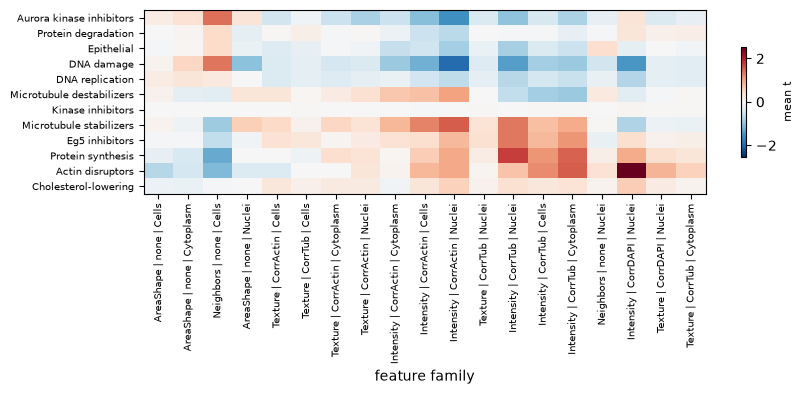

In [14]:
ax = mt.pl.feature_signature(marker, groupby="Metadata_MOA")
plt.show()

One group is missing from that table, and the message explains why: `lactacystin@10.0` is on
no plate that also has control wells, so its treatment effect and plate effect are the same
variable. `differential_features` skips it instead of reporting a number that mixes the two.
This is the same check that makes the blocked test raise above, applied per group.

Compare the rows with what each stain shows. Microtubule stabilizers increase tubulin
intensity in every compartment: taxol bundles microtubules, so there is more tubulin signal.
Eg5 inhibitors concentrate tubulin at the nucleus, which corresponds to a monopolar spindle.
Microtubule destabilizers show up on actin rather than tubulin. They take microtubules apart,
so the tubulin signal drops, and the largest remaining change is the cell rounding up.

So look at the signature instead of assuming it. A drug that targets X does not necessarily
cause its largest measured change in channel X.

## Can the signature recover the mechanisms?

The clustering does not use the labels; they are only used to score it afterwards.

In [15]:
import scanpy as sc
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


def rediscover(profiles, name):
    """Cluster without the labels, then ask how well the clusters match them."""
    labelled = profiles[profiles.obs["Metadata_MOA"].notna().to_numpy()].copy()
    values = np.asarray(labelled.X, dtype=np.float64)
    labelled.X = values / np.maximum(np.linalg.norm(values, axis=1, keepdims=True), 1e-12)
    sc.pp.neighbors(labelled, n_neighbors=8, use_rep="X")
    sc.tl.leiden(labelled, resolution=2.0, flavor="igraph", n_iterations=2, directed=False)
    truth = labelled.obs["Metadata_MOA"].to_numpy()
    found = labelled.obs["leiden"].to_numpy()
    return {
        "representation": name,
        "dimensions": labelled.n_vars,
        "clusters": len(set(found)),
        "ARI": round(adjusted_rand_score(truth, found), 3),
        "NMI": round(normalized_mutual_info_score(truth, found), 3),
    }


consensus = mt.tl.consensus(bbbc, method="median", min_replicates=1)
pd.DataFrame(
    [
        rediscover(signature, "feature families, vs DMSO"),
        rediscover(marker, "feature families, vs rest"),
        rediscover(consensus, "all features, no grouping"),
    ]
)

,representation,dimensions,clusters,ARI,NMI
0,"feature families, vs DMSO",19,11,0.502,0.736
1,"feature families, vs rest",19,9,0.273,0.500
2,"all features, no grouping",344,12,0.687,0.871


There are twelve mechanisms. Clustering on the nineteen feature families (nineteen numbers per
treatment, few enough to print) finds eleven groups that recover them at an NMI of 0.74. The
raw features do better (0.88), as expected with eighteen times the dimensions, but they have no
interpretation.

The two contrasts rank differently here. For nearest-neighbor retrieval, "vs rest" was
better, 0.631 against 0.505 (measured separately with `tl.nn_moa_classify`, not in this
notebook), while for clustering it is much worse. Both follow from the same property: "vs rest"
subtracts what a compound shares with all others, including the compounds with the same
mechanism. That makes an individual compound distinctive but blurs its mechanism group. Use
`contrast="rest"` to tell perturbations apart, and `contrast="reference"` to find which ones
belong together.

## Summary

Most of the expected advantages checked in this notebook did not hold up.

- Test the unit you randomized. Per-cell testing of well-level replicates calls six features
  in ten on a pure null. `tl.differential_features` rejects cell-level input.
- The Mann-Whitney floor limits calls at two wells, not at three. Its smallest possible
  p-value depends on the replication. At two wells against a few hundred controls it is a
  hundred times above the multiple-testing threshold, so no effect of any size can be called.
  At three wells it is the same order as the threshold, and at four it no longer limits
  anything. An earlier version of this notebook claimed a wider limit because it measured the
  floor with identical treated values, which tie and get the normal approximation instead of
  the exact null. `tl.effect_size` had the same bug, and it cost the rank test an order of
  magnitude of replicated findings on rohban. Measure floors with distinct values.
- Rank-transform when the diagnostic says to, not by default. This looked like the largest
  finding until it was measured on four screens. On artificially small pseudo-groups the
  untransformed test produces hundreds of false discoveries on a null and `pp.rank_int` removes
  all of them. At each screen's own replication, though, the untransformed test was already
  calibrated or conservative on all four, and on rohban the transform ties for replicated
  findings. It costs nothing, the consortium's compound recipe already includes it, and
  `mt.metrics.diagnose_testing` tells you whether your screen needs it.
- Once each plate is normalized against its own controls, blocking on plate adds no power, but
  it is the only option that rejects a confounded layout.
- Empirical Bayes shrinkage costs little and changes little here. With a few treated wells
  against many controls the variance is already well estimated, and the moderated t ranks
  features the same as Cohen's d (Spearman 1.00, measured separately, not on this page). It
  helps when both groups are small, for example two treatments compared with each other
  instead of with the controls.

Back to [the API reference](../api.md), which lists every function with what it stores and
its stability guarantee.